# IPCC — Ranking de Regiones por País (CASEN 2024)
## Memoria de Título · Diego Carmine Ortiz · UdeC 2026

Gráficos de ranking de regiones/MSA ordenadas de mayor a menor score IPCC.
Un gráfico por país (Chile, EE.UU., Alemania, España, Francia).

| País | N | Fuente |
|------|---|--------|
| Chile | 16 regiones | `ccpi_chile_m3_2024.csv` |
| EE.UU. | 13 MSA | `ccpi_eeuu_3metodos.csv` |
| Alemania | 13 NUTS-2 | `ccpi_alemania_3metodos.csv` |
| España | 13 NUTS-2 | `ccpi_espana_m3.csv` |
| Francia | 13 NUTS-2 | `ccpi_francia_m3.csv` |


In [1]:
%matplotlib inline

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Serif',
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'axes.edgecolor':    '#BBBBBB',
    'xtick.color':       '#555555',
    'ytick.color':       '#333333',
})

COLOR_TIER = {1: '#8B1A1A', 2: '#E07B39', 3: '#A9A9A9'}
TIER_LABEL = {
    1: 'Tier 1 — Primaria',
    2: 'Tier 2 — Secundaria',
    3: 'Tier 3 — Terciaria',
}

# ── Rutas de datos ─────────────────────────────────────────────
BASE_PROTO = '/Users/diego/Desktop/MT/prototipo_ccpi/data'
BASE_CODE  = '/Users/diego/Desktop/MT/Code/data'

DATOS = {
    'Chile':    (f'{BASE_PROTO}/ccpi_chile_m3_2024.csv',   'region'),
    'EE.UU.':   (f'{BASE_CODE}/ccpi_eeuu_3metodos.csv',    'nombre'),
    'Alemania': (f'{BASE_CODE}/ccpi_alemania_3metodos.csv', 'nombre'),
    'España':   (f'{BASE_PROTO}/ccpi_espana_m3.csv',       'region'),
    'Francia':  (f'{BASE_PROTO}/ccpi_francia_m3.csv',      'region'),
}

dfs = {}
for pais, (path, name_col) in DATOS.items():
    df = pd.read_csv(path)
    df['_nombre'] = df[name_col]
    df['tier']    = df['tier'].astype(int)
    dfs[pais]     = df
    rng = f'{df["CCPI_M3"].min():.3f} – {df["CCPI_M3"].max():.3f}'
    print(f'  {pais:<10}: {len(df):>2d} unidades | CCPI_M3 [{rng}] | tiers: {sorted(df["tier"].unique())}')

# ── Función de gráfico de ranking ──────────────────────────────
def plot_ranking(df, titulo):
    df_ord = df.sort_values('CCPI_M3', ascending=True).reset_index(drop=True)
    n      = len(df_ord)
    alto   = max(6.0, n * 0.52)

    fig, ax = plt.subplots(figsize=(10, alto))
    fig.patch.set_facecolor('white')

    colores = [COLOR_TIER[int(t)] for t in df_ord['tier']]
    barras  = ax.barh(
        y         = df_ord['_nombre'],
        width     = df_ord['CCPI_M3'],
        color     = colores,
        height    = 0.62,
        edgecolor = 'white',
        linewidth = 0.4,
        zorder    = 3,
    )

    # Etiqueta de score al final de cada barra
    x_max = float(df_ord['CCPI_M3'].max())
    for bar, val in zip(barras, df_ord['CCPI_M3']):
        ax.text(
            float(val) + x_max * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center', ha='left',
            fontsize=8, color='#444444',
            fontfamily='DejaVu Serif',
        )

    # Grid sutil solo en X
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color='#E8E0D8', linewidth=0.5, zorder=0)
    ax.set_xlim(0, x_max * 1.12)

    ax.set_xlabel('Score IPCC', fontsize=10, fontfamily='DejaVu Serif', color='#333333')
    ax.tick_params(axis='y', labelsize=9.5)
    ax.tick_params(axis='x', labelsize=8.5, colors='#555555')
    ax.spines['left'].set_color('#BBBBBB')
    ax.spines['bottom'].set_color('#BBBBBB')

    ax.set_title(titulo, fontsize=14, fontweight='bold',
                 fontfamily='DejaVu Serif', pad=14, color='#1A1A1A')

    # Leyenda
    tiers_presentes = sorted(df_ord['tier'].unique())
    handles = [mpatches.Patch(facecolor=COLOR_TIER[t], label=TIER_LABEL[t],
                              edgecolor='white', linewidth=0.4)
               for t in tiers_presentes]
    ax.legend(handles=handles, loc='lower right', fontsize=8.5,
              framealpha=0.92, edgecolor='#CCCCCC',
              prop={'family': 'DejaVu Serif', 'size': 8.5})

    plt.tight_layout()
    display(fig)
    plt.close()
    return n

print('\n✓ Configuración lista — datos cargados para 5 países')


  Chile     : 16 unidades | CCPI_M3 [0.412 – 0.551] | tiers: [np.int64(1), np.int64(2), np.int64(3)]
  EE.UU.    : 13 unidades | CCPI_M3 [0.344 – 0.548] | tiers: [np.int64(1), np.int64(2), np.int64(3)]
  Alemania  : 13 unidades | CCPI_M3 [0.500 – 0.787] | tiers: [np.int64(1), np.int64(2), np.int64(3)]
  España    : 13 unidades | CCPI_M3 [0.452 – 0.578] | tiers: [np.int64(1), np.int64(2), np.int64(3)]
  Francia   : 13 unidades | CCPI_M3 [0.390 – 0.581] | tiers: [np.int64(1), np.int64(2), np.int64(3)]

✓ Configuración lista — datos cargados para 5 países


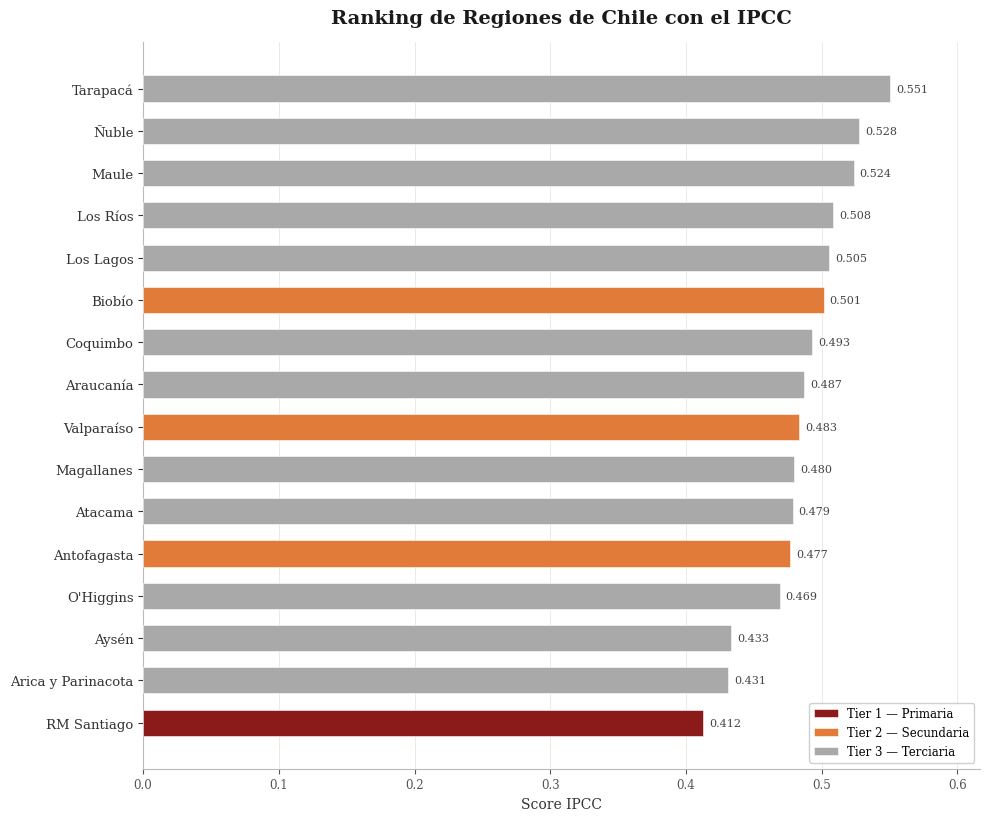

  Chile: 16 unidades


In [2]:
# ── Chile ───────────────────────────────────────────────────────
n_chile = plot_ranking(dfs['Chile'], 'Ranking de Regiones de Chile con el IPCC')
print(f'  Chile: {n_chile} unidades')


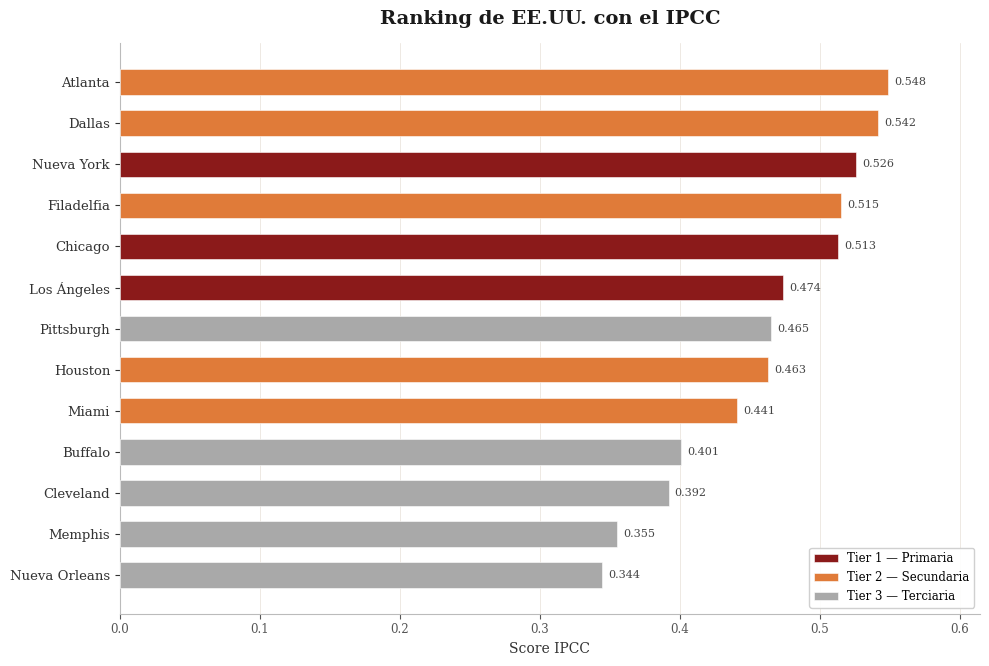

  EE.UU.: 13 unidades


In [3]:
# ── EE.UU. ───────────────────────────────────────────────────────
n_eeuu = plot_ranking(dfs['EE.UU.'], 'Ranking de EE.UU. con el IPCC')
print(f'  EE.UU.: {n_eeuu} unidades')


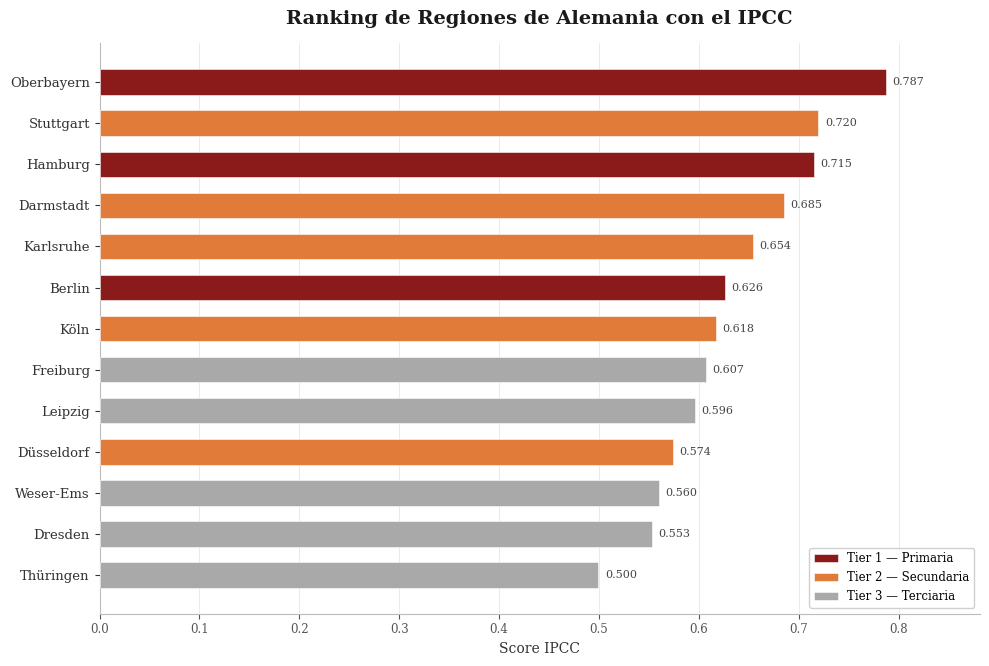

  Alemania: 13 unidades


In [4]:
# ── Alemania ───────────────────────────────────────────────────────
n_alemania = plot_ranking(dfs['Alemania'], 'Ranking de Regiones de Alemania con el IPCC')
print(f'  Alemania: {n_alemania} unidades')


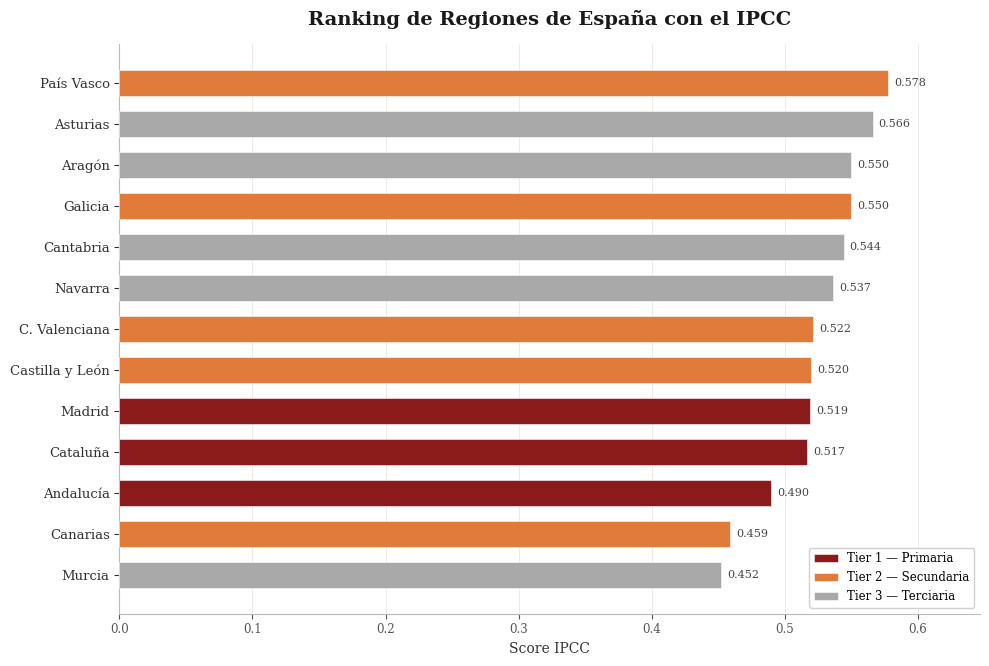

  España: 13 unidades


In [5]:
# ── España ───────────────────────────────────────────────────────
n_espana = plot_ranking(dfs['España'], 'Ranking de Regiones de España con el IPCC')
print(f'  España: {n_espana} unidades')


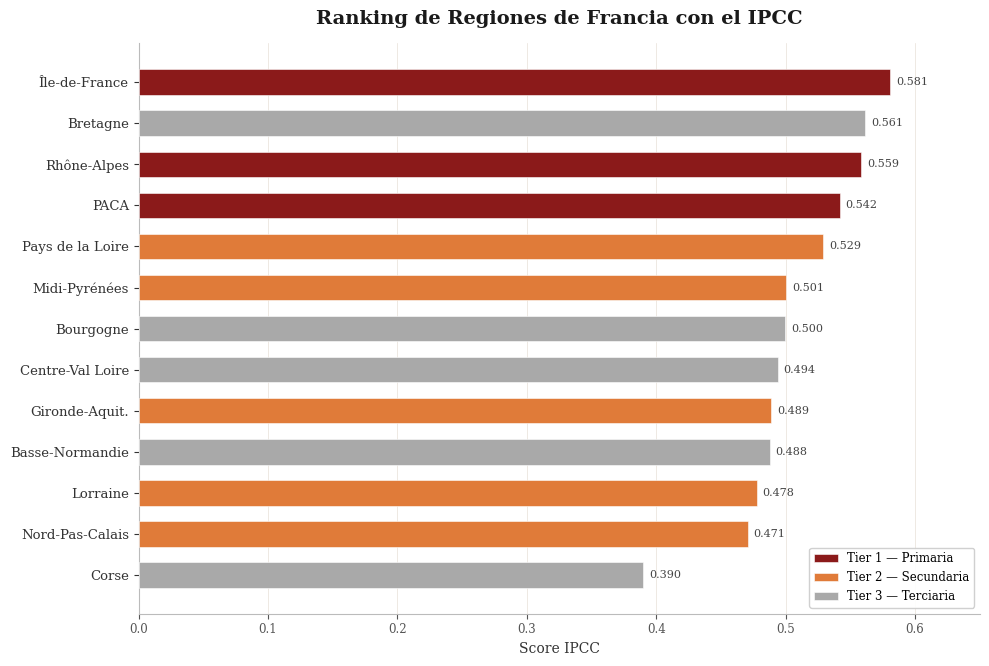

  Francia: 13 unidades


In [6]:
# ── Francia ───────────────────────────────────────────────────────
n_francia = plot_ranking(dfs['Francia'], 'Ranking de Regiones de Francia con el IPCC')
print(f'  Francia: {n_francia} unidades')


In [7]:
# ── Resumen final ─────────────────────────────────────────────
print()
print('✓ 5 rankings generados (sin guardar en disco)')
for pais, (path, name_col) in DATOS.items():
    n    = len(dfs[pais])
    unit = 'MSA' if pais == 'EE.UU.' else 'regiones'
    print(f'  {pais:<12}: {n:>2d} {unit}')



✓ 5 rankings generados (sin guardar en disco)
  Chile       : 16 regiones
  EE.UU.      : 13 MSA
  Alemania    : 13 regiones
  España      : 13 regiones
  Francia     : 13 regiones
